In [1]:
import os
import time
import umap
import yaml
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import datetime as datetime
import matplotlib.pyplot as plt 
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset, default_collate
from mm_cgmvae import *
from train_mmvae import*
from VAE_model_architectures import*

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
params = {
    'general': {
'dataset': 'DO',  # AD
'model_type': 'CGMVAE', # VAE or CVAE or GMVAE 
'random_seed': 10, # 85 # 123 for same region, seed 22 for multi-region no offset, 22 for multi-region offset
'learn_prior': False,
'accelerator': True,
'M': 2,
'epochs': 10000,
'num_iwae_samples': 1, 
'learning_rate': 1e-3, 
'offset_centers': False
    }
}
dataset = params['general']['dataset']
model_type = params['general']['model_type']
random_seed = params['general']['random_seed']
learn_prior = params['general']['learn_prior']
accelerator = params['general']['accelerator']
M = params['general']['M']
epochs = params['general']['epochs']
num_iwae_samples = params['general']['num_iwae_samples']
learning_rate = params['general']['learning_rate']
offset_centers = params['general']['offset_centers']

In [3]:
dataset_params = {
'input_dim': [5873, 33],
# 'H1': [128, 25], 
# 'H2': [64, 16], 
# 'H3': [32, 10],
'hidden_dims1': [128, 64, 32, 16, 12], 
'hidden_dims2': [25, 22, 18, 14, 10],
'latent_dim': 10,
'batch_size': 501, # 501 = full batch
'scales': [1, 1],
'dataset_abbrev': ['Geno', 'Physio'],
'output_folder': '/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/cgmvae_Dtarget1_newdata_T0.01',
#'input_path': '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio_restandardized_cfc.csv',
'input_path': '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/do_mice_data_standardized.csv',
#'gmm_centers_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers_4gaussian_14mon_fromQRT.csv',
'gmm_std': 0.05,
'num_classes': 4,
'num_kl_samples': 100,
'train_overlap': True, 
'outcome': 'cfm', 
'kl_annealing': False,
'mode': 'single', 
'd_target': 0.1,
'temperature': 0.01
}
params['dataset_params'] = dataset_params
input_dim = params['dataset_params']['input_dim']
hidden_dims1 = params['dataset_params']['hidden_dims1']
hidden_dims2 = params['dataset_params']['hidden_dims2']
# H1 = params['dataset_params']['H1']
# H2 = params['dataset_params']['H2']
# H3 = params['dataset_params']['H3']
latent_dim = params['dataset_params']['latent_dim']
batch_size = params['dataset_params']['batch_size']
scales = params['dataset_params']['scales']
dataset_abbrev = params['dataset_params']['dataset_abbrev']
output_folder = params['dataset_params']['output_folder']
input_path = params['dataset_params']['input_path']
#gmm_centers_path = params['dataset_params']['gmm_centers_path']
gmm_std = params['dataset_params']['gmm_std']
num_classes = params['dataset_params']['num_classes']
num_kl_samples = params['dataset_params']['num_kl_samples']
train_overlap = params['dataset_params']['train_overlap']
outcome = params['dataset_params']['outcome']
kl_annealing = params['dataset_params']['kl_annealing']
mode = params['dataset_params']['mode']
d_target = params['dataset_params']['d_target']
temperature = params['dataset_params']['temperature']

In [4]:
# initialize device 
# set device to gpu if available 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# create output folder 
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# save params in a yaml file 
with open(f"{output_folder}/config.yaml", "w") as f:
    yaml.dump(params, f)

In [5]:
def set_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
set_seed(random_seed)

In [73]:
def numpyToTensor(x):
    return torch.from_numpy(x)

In [9]:
paired_df = pd.read_csv(input_path, low_memory=False)
paired_df['SurvDays']

0       895
1       925
2      1166
3      1042
4       811
       ... 
496     735
497     973
498     832
499    1017
500     750
Name: SurvDays, Length: 501, dtype: int64

In [72]:
paired_df = pd.read_csv(input_path, low_memory=False)
physio_cols = paired_df.iloc[:, input_dim[0]+3:input_dim[0]+input_dim[1]+3].columns
physio_cols = list(physio_cols)
physio_cols.append('cfm')
physio_cols.append('lifespan')
label_col = 'cfc_bin'
cfm_col = 'CFC.24mo.Average'
life_col = 'SurvDays'
mouse_id_col = 'MouseID'
diet_col = 'Diet'
paired_df[cfm_col] = standardizer(paired_df[cfm_col], 'cfm')
paired_df[life_col] = standardizer(paired_df[life_col], 'lifespan')
paired_df, cfc_bin_edges = assign_cfc_bins(paired_df, cfm_col, num_classes, label_col)
print(paired_df[label_col].value_counts().sort_index())
paired_df_train = paired_df.sample(frac=1, random_state=random_seed)
train_dataset = PairedDataset(paired_df_train, input_dim, label_col, cfm_col, life_col, mouse_id_col, diet_col)
test_dataset = PairedDataset(paired_df, input_dim, label_col, cfm_col, life_col, mouse_id_col, diet_col)

cfc_bin
0    120
1    155
2    145
3     81
Name: count, dtype: int64


In [11]:
paired_df['SurvDays']

0     -0.621813
1     -0.453265
2      0.900743
3      0.204075
4     -1.093750
         ...   
496   -1.520740
497   -0.183587
498   -0.975766
499    0.063618
500   -1.436465
Name: SurvDays, Length: 501, dtype: float64

In [ ]:
def _seed_worker(worker_id):
    worker_seed = random_seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(random_seed)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, worker_init_fn=_seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), num_workers=0, worker_init_fn=_seed_worker, generator=g)

In [ ]:
if model_type == 'CGMVAE':
    gmm_centers = []
    ks_weights = []
    cv_weights = []
    all_samples = []
    for dataset in dataset_abbrev:
        # gmm_path = f"/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/{dataset}_priors_0.5std.csv"
        # gmm_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/do_gmm_centers.csv' # same centers
        # gmm_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/do_gmm_centers_comp.csv' # compressed centers
        # gmm_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/do_gmm_centers_range5.csv' # even more compressed centers
        # gmm_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/do_gmm_centers_range4.csv'
        gmm_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/do_gmm_centers_range2.csv'
        # gmm_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/do_gmm_6centers_range4.csv'
        # gmm_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/do_gmm_8centers.csv'
        gmm = pd.read_csv(gmm_path)
        gmm = gmm.iloc[:, 1:].T
        ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, torch.tensor([gmm.values]).float().squeeze(), gmm_std, num_kl_samples)
        samples_df = pd.DataFrame(samples)
        samples_df['components'] = components 
        all_samples.append(samples_df)
        samples_df.to_csv(os.path.join(output_folder, f'gmm_samples_{dataset}encoder.csv'), index=False)
        gmm_centers.append(torch.tensor([gmm.values]).float().squeeze())
        ks_weights.append(ks_weight)
        cv_weights.append(cv_weight)

/tmp/ipykernel_457563/3893876812.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, torch.tensor([gmm.values]).float().squeeze(), gmm_std, num_kl_samples)


In [14]:
weights_df = pd.concat([pd.Series(ks_weights), pd.Series(cv_weights)], axis=1)
weights_df.columns = ['KS', 'CV']
weights_df.to_csv(os.path.join(output_folder, 'ks_cv_weights.csv'))

In [15]:
model = MM_CGMVAE(input_dim, [hidden_dims1, hidden_dims2], latent_dim, scales, num_classes, gmm_centers, gmm_std, ks_weights, cv_weights)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, amsgrad=False)

In [16]:
num_encoders = len(dataset_abbrev)
pairs = [(src, tgt) for src in dataset_abbrev for tgt in dataset_abbrev]
checkpoint_epochs = set(np.linspace(1, epochs, 5).astype(int))

total_loss = []
overlap_epochs = []
geno_overlap = []
physio_overlap = []
overall_overlap = []
corr_epochs = []
geno_corr = []
physio_corr = []
overall_corr = []
total_test_loss = []
test_epochs = []
bin_means_epochs = []

individual_loss = {f'{enc}_{name}': [] for enc in dataset_abbrev for name in ('lpx_z', 'kls')}
recon_loss = {f'{src}_{tgt}': [] for src, tgt in pairs}
mse_losses = {f'{src}_{tgt}': [] for src, tgt in pairs}
mse_cfm_losses = {f'{src}_{tgt}': [] for src, tgt in pairs}
mse_lifespan_losses = {f'{src}_{tgt}': [] for src, tgt in pairs}

In [17]:
start_time = time.time()
train_loader_len = len(train_loader)

for epoch in range(1, epochs + 1):
    output = train(
        epoch, model, optimizer, train_loader, num_iwae_samples, device, epochs, model_type, mode, d_target, temperature, train_overlap, kl_annealing
    )

    loss = output['overall_loss']
    lpx_zs = output['lpx_zs']
    kls = output['kls']
    lpxz_ind = output['lpxz_ind']
    mse_loss = output['mse_loss']
    mse_cfm_loss = output['mse_cfm_loss']
    mse_lifespan_loss = output['mse_lifespan_loss']
    overlap = output['overall_overlap']
    overlap_vals = output['overlap_vals']
    corr = output['overall_corr']
    corr_vals = output['corr_vals']
    bin_means = output['bin_means']
    endpoints = output['endpoints'].detach().cpu().numpy()

    print(f'Epoch {epoch} done')
    overlap_epochs.append(overlap.detach().cpu().numpy())
    corr_epochs.append(corr.detach().cpu().numpy())
    if mode == 'single':
        geno_overlap.append(overlap_vals[0].detach().cpu().numpy())
        physio_overlap.append(overlap_vals[1].detach().cpu().numpy())
        overall_overlap.append(overlap_vals[2].detach().cpu().numpy())
        geno_corr.append(corr_vals[0].detach().cpu().numpy())
        physio_corr.append(corr_vals[1].detach().cpu().numpy())
        overall_corr.append(corr_vals[2].detach().cpu().numpy())
    else: 
        geno_overlap.append(overlap_vals[0].detach().cpu().numpy())
        physio_overlap.append(overlap_vals[0].detach().cpu().numpy())
        overall_overlap.append(overlap_vals[2].detach().cpu().numpy())
        geno_corr.append(corr_vals[0].detach().cpu().numpy())
        physio_corr.append(corr_vals[0].detach().cpu().numpy())
        overall_corr.append(corr_vals[0].detach().cpu().numpy())

    total_loss.append(loss.detach().cpu().numpy())
    bin_means_epochs.append(bin_means)

    for enc_idx, encoder in enumerate(dataset_abbrev):
        individual_loss[f'{encoder}_lpx_z'].append(lpx_zs[enc_idx])
        individual_loss[f'{encoder}_kls'].append(kls[enc_idx])

        for dec_idx, decoder in enumerate(dataset_abbrev):
            flat_idx = enc_idx * num_encoders + dec_idx
            key = f'{encoder}_{decoder}'

            recon_loss[key].append(lpxz_ind[flat_idx] / train_loader_len)
            mse_losses[key].append(mse_loss[flat_idx])
            mse_cfm_losses[key].append(mse_cfm_loss[flat_idx])
            mse_lifespan_losses[key].append(mse_lifespan_loss[flat_idx])

    if epoch in checkpoint_epochs:
        test_epochs.append(epoch)
        test(epoch, model, optimizer, test_loader, num_iwae_samples, device, output_folder, dataset_abbrev, physio_cols, mode, d_target, temperature)

end_time = time.time() 
print(f'{end_time - start_time} sesconds for training/testing')

====> Epoch: 001 Train loss: 1461.9900
Epoch 1 done
Encoded features from Geno encoder saved
Reconstructed Geno data from Geno encoder saved
Reconstructed Physio data from Geno encoder saved
Encoded features from Physio encoder saved
Reconstructed Geno data from Physio encoder saved
Reconstructed Physio data from Physio encoder saved
Finished test reconstruction
Model saved
====> Epoch: 002 Train loss: 1117.8502
Epoch 2 done
====> Epoch: 003 Train loss: 1121.4097
Epoch 3 done
====> Epoch: 004 Train loss: 1018.4576
Epoch 4 done
====> Epoch: 005 Train loss: 1059.3962
Epoch 5 done
====> Epoch: 006 Train loss: 1002.3671
Epoch 6 done
====> Epoch: 007 Train loss: 992.6208
Epoch 7 done
====> Epoch: 008 Train loss: 1079.5848
Epoch 8 done
====> Epoch: 009 Train loss: 965.6367
Epoch 9 done
====> Epoch: 010 Train loss: 1043.0365
Epoch 10 done
====> Epoch: 011 Train loss: 985.0024
Epoch 11 done
====> Epoch: 012 Train loss: 1006.8809
Epoch 12 done
====> Epoch: 013 Train loss: 879.9582
Epoch 13 done

In [18]:
# Save loss vectors 
pd.DataFrame(total_loss).to_csv(os.path.join(output_folder, 'total_loss.csv'), index=False)
pd.DataFrame(individual_loss).to_csv(os.path.join(output_folder, 'individual_loss.csv'), index=False)
pd.DataFrame(recon_loss).to_csv(os.path.join(output_folder, 'recon_loss.csv'), index=False)
pd.DataFrame(mse_losses).to_csv(os.path.join(output_folder, 'mse_losses.csv'), index=False)
pd.DataFrame(mse_cfm_losses).to_csv(os.path.join(output_folder, 'mse_cfm_losses.csv'), index=False)
pd.DataFrame(overlap_epochs).to_csv(os.path.join(output_folder, 'overlap_over_epochs.csv'), index=False)
pd.DataFrame(corr_epochs).to_csv(os.path.join(output_folder, 'corr_over_epochs.csv'), index=False)
pd.DataFrame(bin_means_epochs).to_csv(os.path.join(output_folder, 'bin_means_epochs.csv'), index=False)
pd.DataFrame(bin_means_epochs).to_csv(os.path.join(output_folder, 'bin_means_epochs.csv'), index=False)
pd.DataFrame(endpoints).to_csv(os.path.join(output_folder, 'endpoints.csv'), index=False)

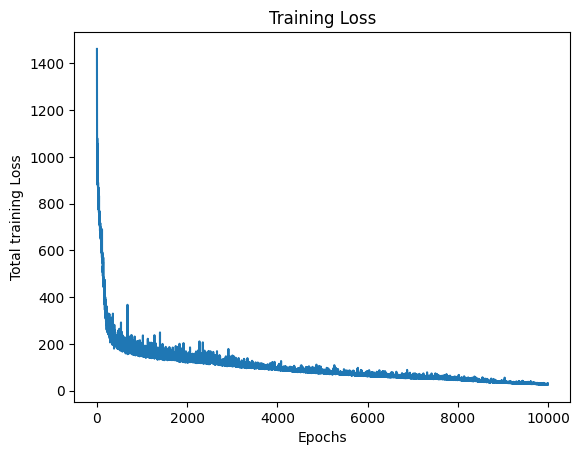

In [19]:
plt.figure()
plt.plot(total_loss, label='Training loss')                                                                          
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Total training Loss')            
plt.savefig(os.path.join(output_folder, 'train_loss.png'))

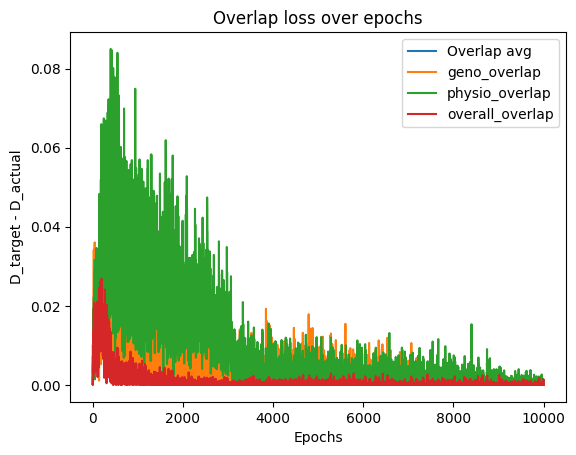

In [20]:
plt.figure()
plt.plot((overlap_epochs), label='Overlap avg')
plt.plot(geno_overlap, label='geno_overlap')
plt.plot(physio_overlap, label='physio_overlap')
plt.plot(overall_overlap, label='overall_overlap')                                                                          
plt.title('Overlap loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('D_target - D_actual')
plt.legend()            
plt.savefig(os.path.join(output_folder, 'overlap_over_epochs.png'))

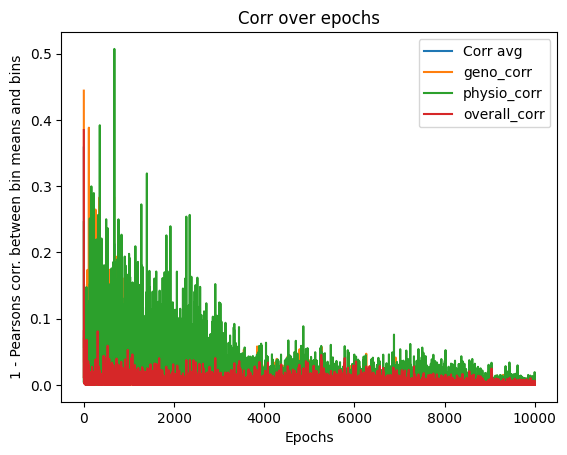

In [21]:
plt.figure()
plt.plot((corr_epochs), label='Corr avg')
plt.plot(geno_corr, label='geno_corr')
plt.plot(physio_corr, label='physio_corr')
plt.plot(overall_corr, label='overall_corr')                                                                          
plt.title('Corr over epochs')
plt.xlabel('Epochs')
plt.ylabel('1 - Pearsons corr. between bin means and bins')
plt.legend()            
plt.savefig(os.path.join(output_folder, 'corr_over_epochs.png'))

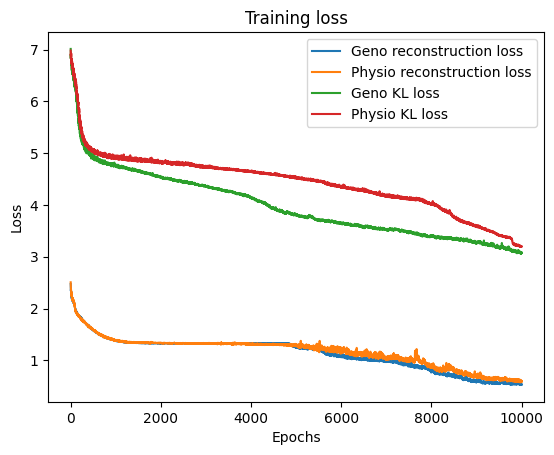

In [22]:
plt.figure()
names = ['reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        plt.plot(np.log(individual_loss[f'{dataset_abbrev[j]}_{set}']), label=f'{dataset_abbrev[j]} {names[i]}')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(os.path.join(output_folder, 'recon_kl_oneplot.png'))

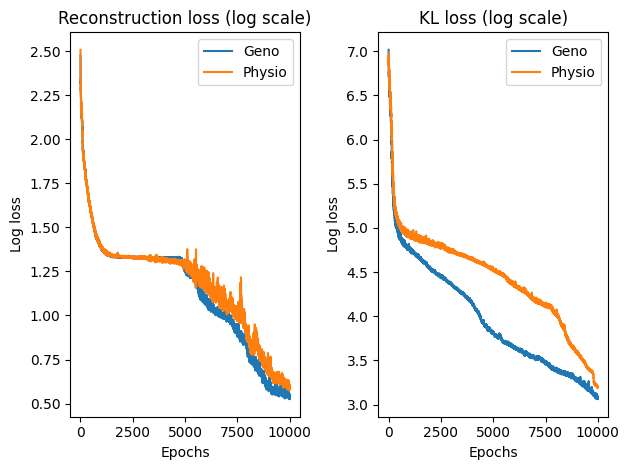

In [23]:
fig, ax = plt.subplots(1, 2)
names = ['Reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        ax[i].plot(np.log(individual_loss[f'{dataset_abbrev[j]}_{set}']), label=f'{dataset_abbrev[j]}')
    ax[i].set_title(f'{names[i]} (log scale)')
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Log loss')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs_log.png'))

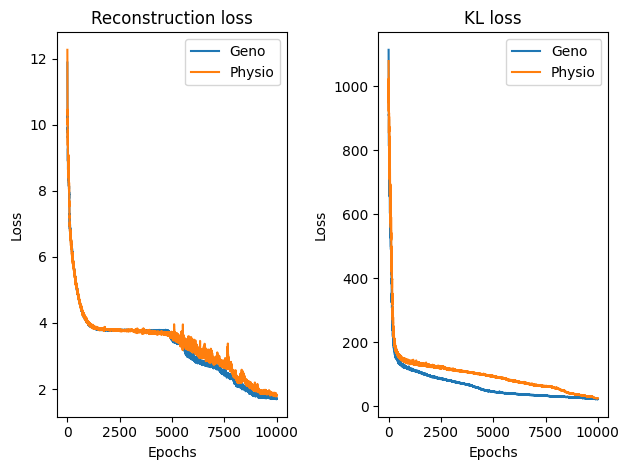

In [24]:
fig, ax = plt.subplots(1, 2)
names = ['Reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        ax[i].plot(individual_loss[f'{dataset_abbrev[j]}_{set}'], label=f'{dataset_abbrev[j]}')
    ax[i].set_title(names[i])
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Loss')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs.png'))

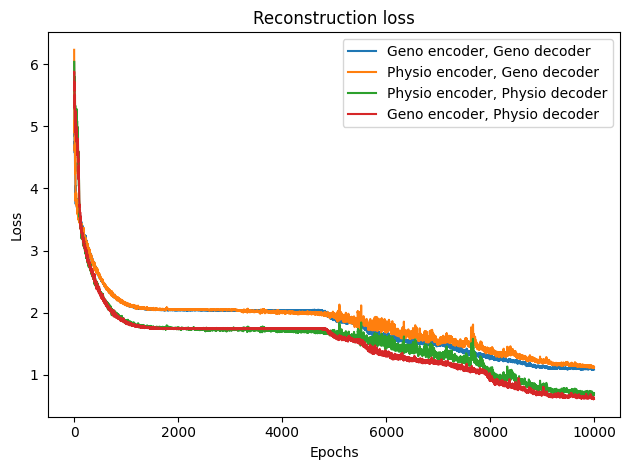

In [25]:
# Plotting each kind of reconstruction
for i, set in enumerate(dataset_abbrev):
    plt.plot((recon_loss[f'{set}_{set}']), label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((recon_loss[f'{dataset_abbrev[i+1]}_{set}']), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((recon_loss[f'{dataset_abbrev[i-1]}_{set}']), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Reconstruction loss')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_recon_loss_graphs.png'))

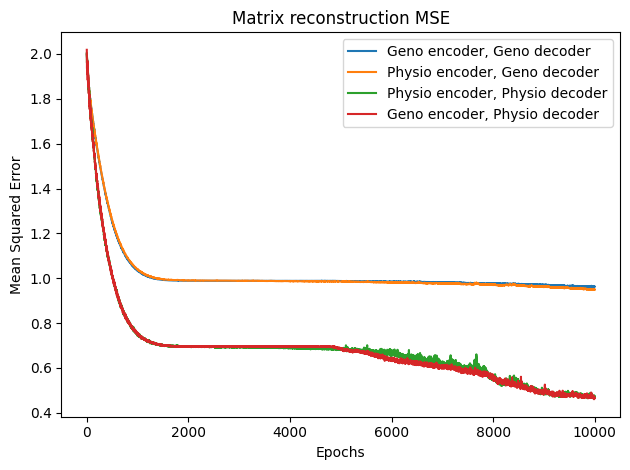

In [26]:
# Plotting each kind of reconstruction
for i, set in enumerate(dataset_abbrev):
    plt.plot(mse_losses[f'{set}_{set}'], label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((mse_losses[f'{dataset_abbrev[i+1]}_{set}']), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((mse_losses[f'{dataset_abbrev[i-1]}_{set}']), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Matrix reconstruction MSE')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_mse_graphs.png'))

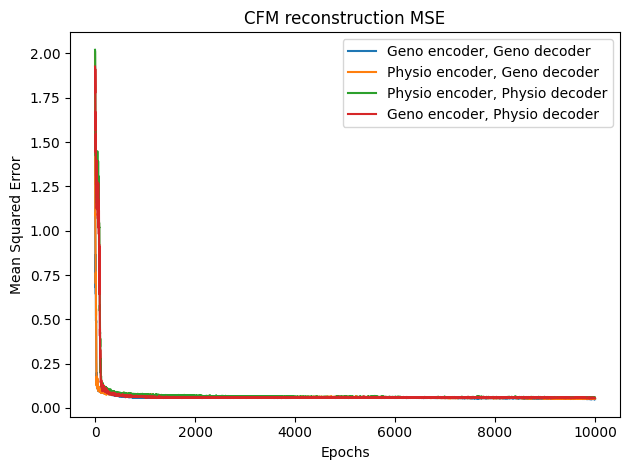

In [27]:
# Plotting each kind of reconstruction (cfm mse)
for i, set in enumerate(dataset_abbrev):
    plt.plot(mse_cfm_losses[f'{set}_{set}'], label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((mse_cfm_losses[f'{dataset_abbrev[i+1]}_{set}']), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((mse_cfm_losses[f'{dataset_abbrev[i-1]}_{set}']), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('CFM reconstruction MSE')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_mse_cfm_graphs.png'))

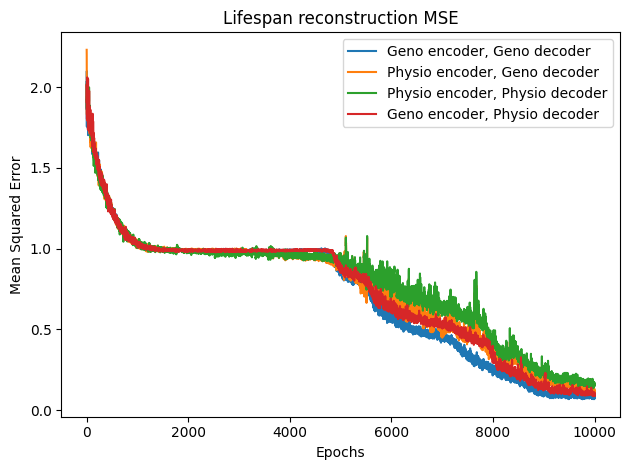

In [28]:
# Plotting each kind of reconstruction (lifespan mse)
for i, set in enumerate(dataset_abbrev):
    plt.plot(mse_lifespan_losses[f'{set}_{set}'], label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((mse_lifespan_losses[f'{dataset_abbrev[i+1]}_{set}']), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((mse_lifespan_losses[f'{dataset_abbrev[i-1]}_{set}']), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Lifespan reconstruction MSE')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_mse_lifespan_graphs.png'))

Visualizing the latent space

In [29]:
hues=['Encoder', 'Bin', 'Diet']

In [30]:
latent_space_1 = latent_space_1 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[0]}.csv'), index_col=False)
latent_space_2 = latent_space_2 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[1]}.csv'), index_col=False)

In [31]:
latent_space_1.columns = latent_space_1.columns.str.replace(f'_{dataset_abbrev[0]}', '')
latent_space_2.columns = latent_space_2.columns.str.replace(f'_{dataset_abbrev[1]}', '')

In [32]:
latent_space_comb = pd.concat([latent_space_1, latent_space_2])
latent_space_comb = latent_space_comb.reset_index(drop=True)

In [33]:
prior_samples = pd.DataFrame(samples)
prior_samples['components'] = components

In [34]:
# sns.kdeplot(data=latent_space_comb['LV1'], fill=True)

In [35]:
# for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
#     fig, ax = plt.subplots(1, 2, figsize=(12, 3))
#     sns.kdeplot(data=latent_space_comb[[column, 'Encoder']], x=column, hue='Encoder', fill=True, bw_adjust=1, ax=ax[0])
#     ax[0].set_title(column)
#     prior_col = prior_samples.columns[i]
#     sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
#     ax[1].set_title(f'{column} prior distribution')

In [36]:
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
# custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
# for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
#     fig, ax = plt.subplots(1, 2, figsize=(12, 3))
#     sns.kdeplot(data=latent_space_comb[[column, 'Bin']], x=column, hue='Bin', palette = custom_palette, fill=True, bw_adjust=3, ax=ax[0])
#     ax[0].set_title(column)
#     prior_col = prior_samples.columns[i]
#     sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
#     ax[1].set_title(f'{column} prior distribution')

/tmp/ipykernel_457563/593382335.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_457563/593382335.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


In [37]:
latent_space_comb['bin_enc'] = latent_space_comb['Bin'].astype(str) + '_' +  latent_space_comb['Encoder']

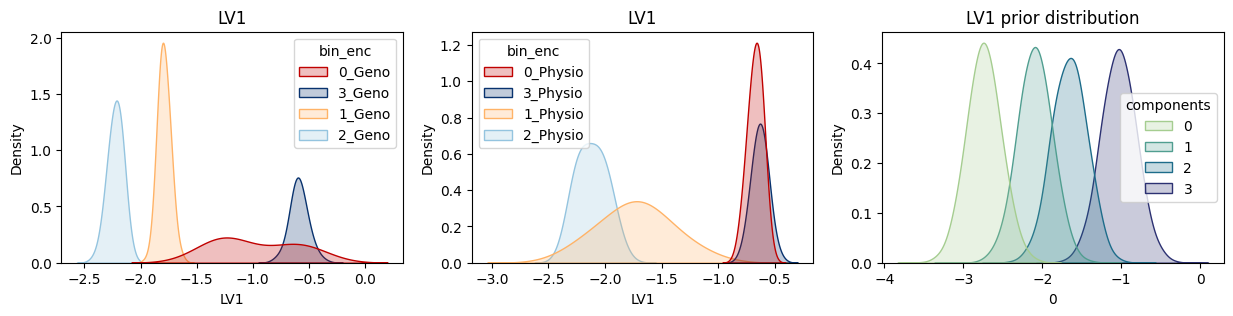

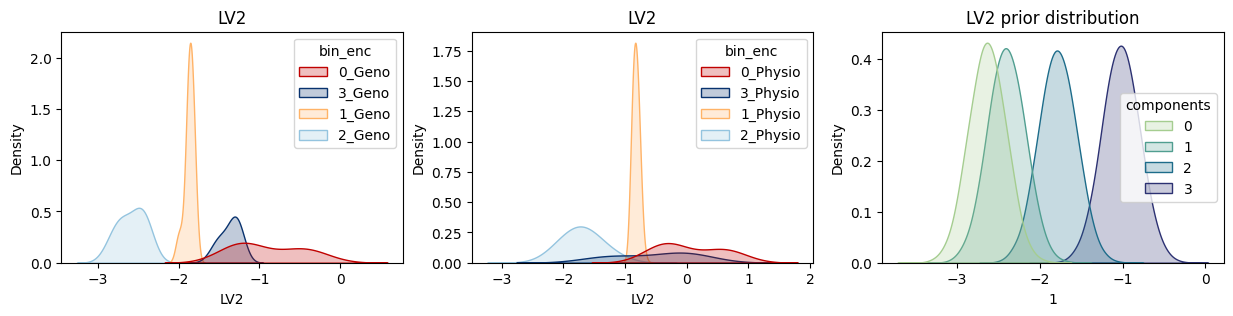

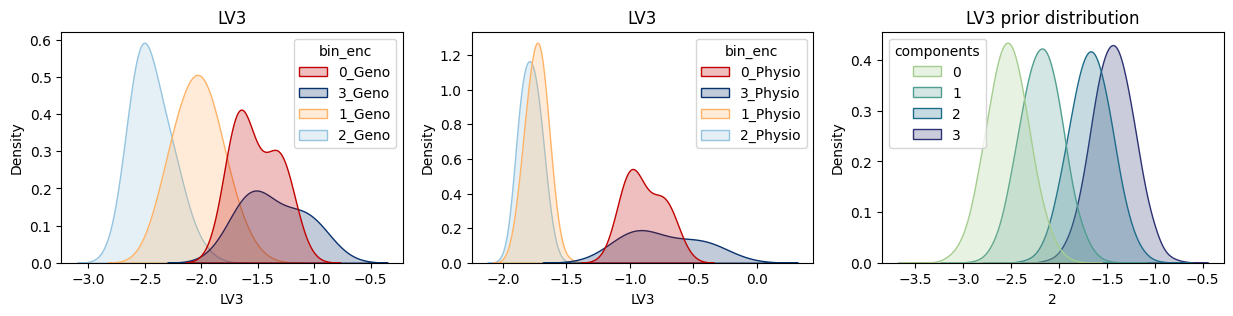

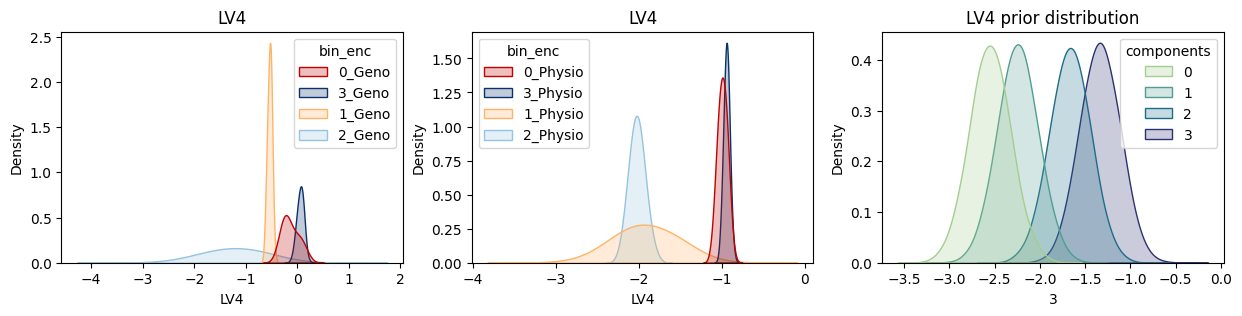

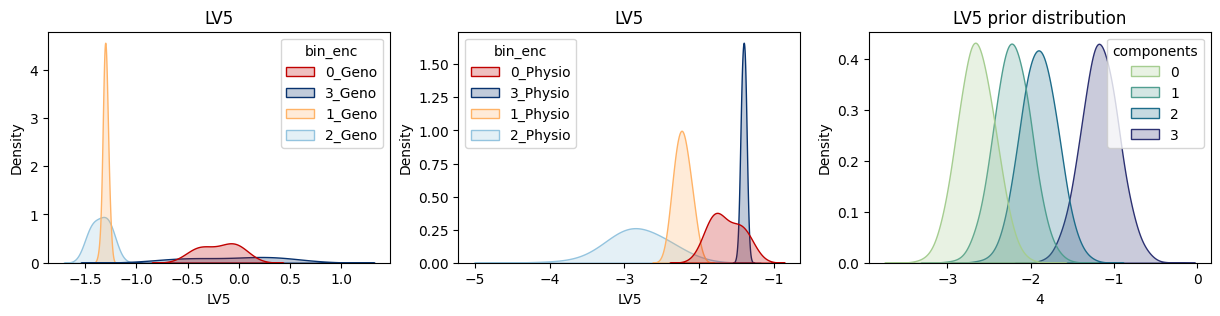

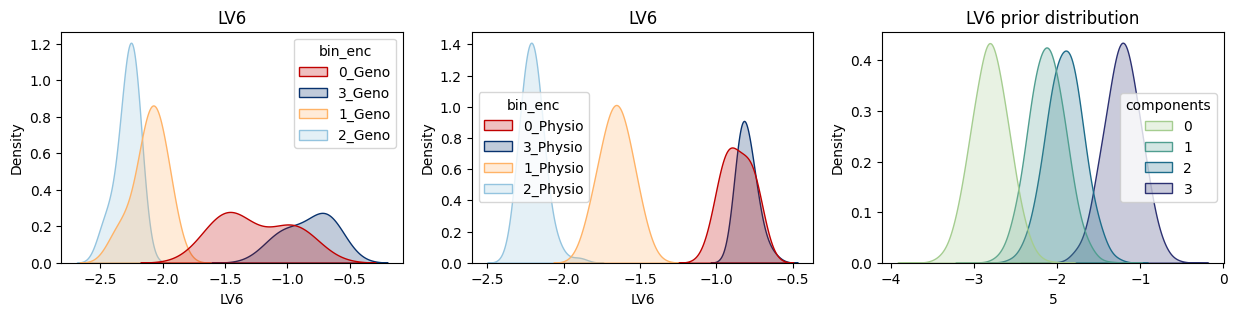

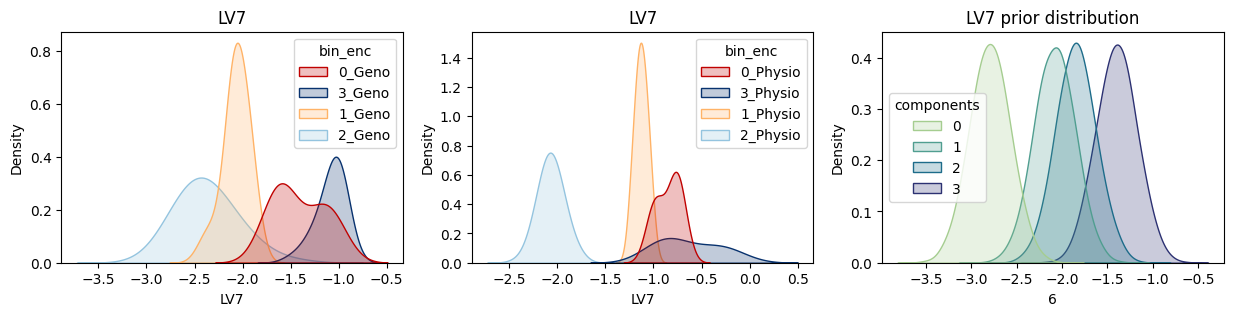

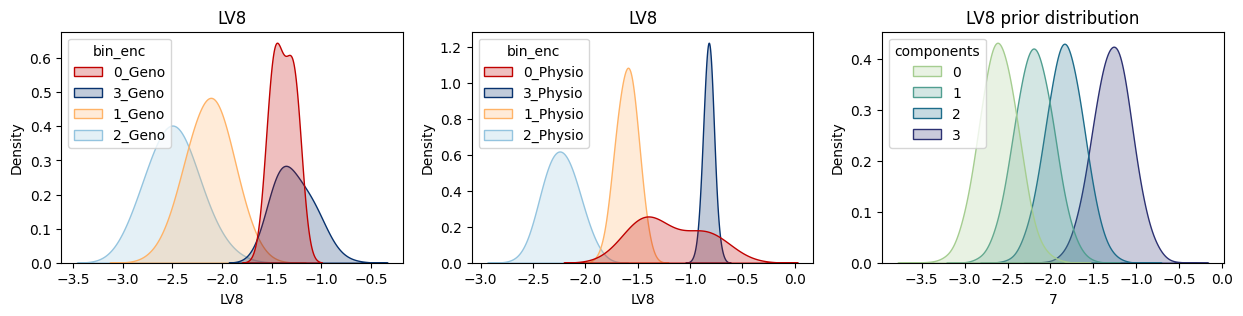

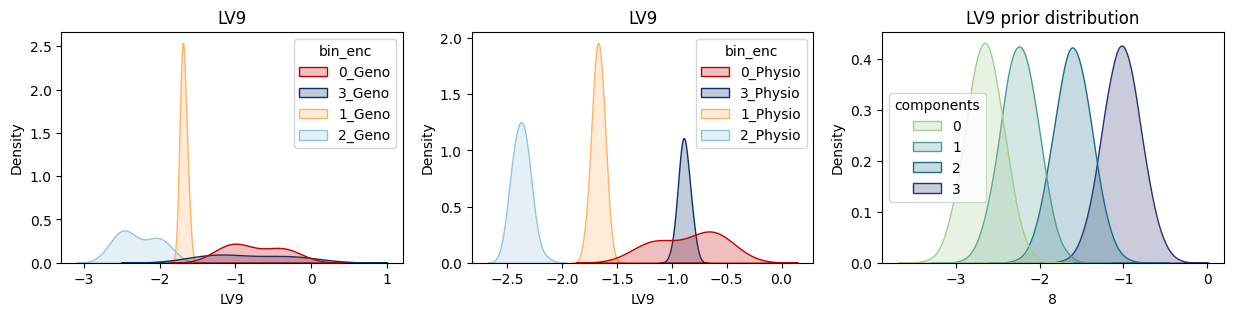

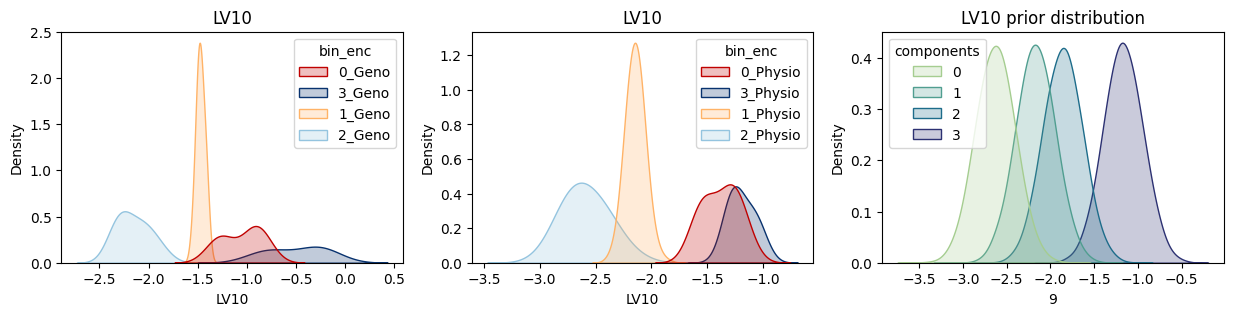

In [38]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    palette_HC = {f'0_{dataset_abbrev[0]}': cmap1(0.5), f'1_{dataset_abbrev[0]}': cmap1(0.85), f'2_{dataset_abbrev[0]}': cmap2(0.4), f'3_{dataset_abbrev[0]}': cmap2(0.99)}
    hc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[0])]
    sns.kdeplot(data=hc[[column, 'bin_enc']], x=column, hue='bin_enc', palette=palette_HC, fill=True, bw_adjust=2, ax=ax[0])
    ax[0].set_title(column)
    palette_HC2 = {f'0_{dataset_abbrev[1]}': cmap1(0.5), f'1_{dataset_abbrev[1]}': cmap1(0.85), f'2_{dataset_abbrev[1]}': cmap2(0.4), f'3_{dataset_abbrev[1]}': cmap2(0.99)}
    #palette_PFC = {'0_PFC': cmap1(0.5), '1_PFC': cmap1(0.85), '2_PFC': cmap2(0.4), '3_PFC': cmap2(0.99)}
    pfc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[1])]
    sns.kdeplot(data=pfc[[column, 'bin_enc']], x=column, hue='bin_enc', palette=palette_HC2, fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
    ax[2].set_title(f'{column} prior distribution')

Plot the centers over epochs

In [39]:
from scipy.stats import norm

In [40]:
def plot_latent_progression(epoch_data_list, overlap_epochs, gmm_centers, latent_dim, std=0.2, every_n_epochs=500, output_folder='.'):
    # epoch_data_list structure: [num_epochs][num_encoders][num_bins (of latent_dim size)]
    # gmm_centers structure: [num_epochs][num_encoders][num_bins][latent_dim]
    
    epochs_to_plot = range(0, len(epoch_data_list), every_n_epochs)
    num_plots = len(epochs_to_plot)
    
    fig, axes = plt.subplots(num_plots, 2, figsize=(14, num_plots * 1.5), sharex=True)
    if num_plots == 1: axes = np.expand_dims(axes, axis=0)
    
    # Calculate global limits based on the nested structure
    all_means = [bin_data[latent_dim] for epoch in epoch_data_list for encoder in epoch for bin_data in encoder]
    all_means = np.array(all_means)
    xmin, xmax = np.min(all_means) - 3*std, np.max(all_means) + 3*std
    x = np.linspace(xmin, xmax, 500)
    colors = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71']

    for i, epoch_idx in enumerate(epochs_to_plot):
        overlap = overlap_epochs[epoch_idx]
        
        # Accessing nested lists for current epoch
        current_epoch_data = epoch_data_list[epoch_idx] # list of 2 encoders
        current_epoch_centers = gmm_centers # list of 2 encoders
        
        for enc_idx in range(2):
            ax = axes[i, enc_idx]
            encoder_bins = current_epoch_data[enc_idx]
            encoder_centers = current_epoch_centers[enc_idx]
            
            for bin_idx in range(len(encoder_bins)):
                # Access latent_dim from the bin vector
                m = encoder_bins[bin_idx][latent_dim]
                y = norm.pdf(x, m, std)
                
                ax.plot(x, y, color=colors[bin_idx % len(colors)], lw=1.5, alpha=0.8, label=f'Bin {bin_idx}')
                ax.fill_between(x, y, color=colors[bin_idx % len(colors)], alpha=0.3)
                
                # Plot GMM center as a red dot
                center_val = encoder_centers[bin_idx][latent_dim]
                ax.scatter(center_val, 0, color='red', zorder=5, s=30, marker='o')

            if i == 0:
                ax.set_title(f"Encoder {dataset_abbrev[enc_idx]}")
                ax.legend()
            if enc_idx == 0:
                ax.set_ylabel(f"Epoch {epoch_idx}\noverlap: {overlap:.4f}", 
                              fontweight='bold', rotation=0, labelpad=50, va='center')
            
            ax.set_yticks([])
            ax.spines[['top', 'right', 'left']].set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(f"Progression of Bin Separation (Dim {latent_dim})", y=0.98)
    
    save_path = os.path.join(output_folder, f'bins_dim_{latent_dim}_over_epochs.png')
    plt.savefig(save_path)
    plt.show()

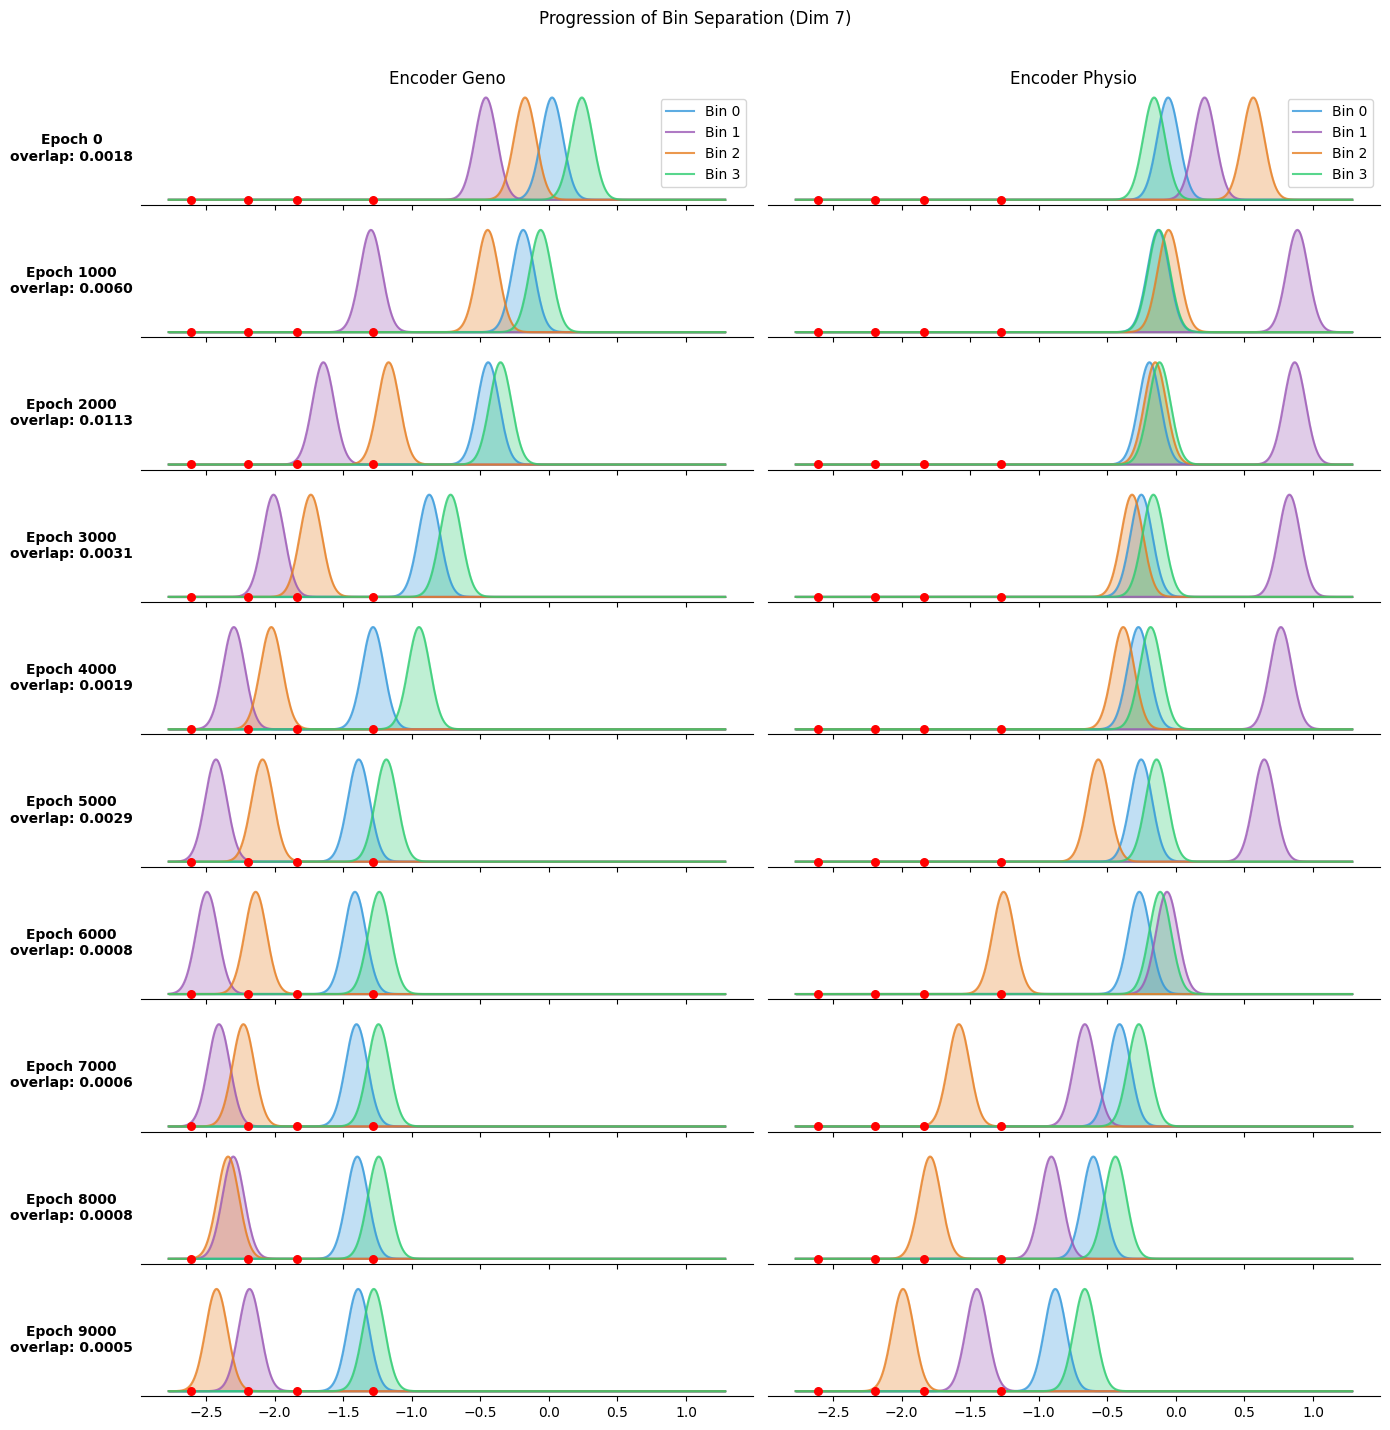

In [41]:
plot_latent_progression(bin_means_epochs, overlap_epochs, gmm_centers, 7, 0.08, 1000, output_folder)

Plot phenotypic projection over time

In [42]:
# pheno_proj_1 = pd.read_csv(os.path.join(output_folder, f'phenotypic_projection_epoch{epochs}_vae{dataset_abbrev[0]}.csv'), index_col=False)
# pheno_proj_2 = pd.read_csv(os.path.join(output_folder, f'phenotypic_projection_epoch{epochs}_vae{dataset_abbrev[1]}.csv'), index_col=False)

In [43]:
# pheno_proj = pd.read_csv(os.path.join(output_folder, f'phenotypic_projection_epoch5.csv'), index_col=False)
# pheno_proj

In [44]:
# geno_proj = pd.read_csv(os.path.join(output_folder, f'Geno_phenotypic_projection_epoch20000.csv'), index_col=False)
# geno_proj

In [45]:
def plot_pheno_proj_progression(output_folder, total_epochs):
    epochs_to_plot = np.linspace(1, total_epochs, 5).astype(int)
    fig, axes = plt.subplots(len(epochs_to_plot), 3, figsize=(20, len(epochs_to_plot)*1.5), sharex=True)

    cmap1 = cm.get_cmap('gist_heat')
    cmap2 = cm.get_cmap('Blues')
    custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
    
    for enc_idx, dataset in enumerate(dataset_abbrev):
        for i, epoch in enumerate(epochs_to_plot):
            pheno_proj = pd.read_csv(os.path.join(output_folder, f'{dataset}_phenotypic_projection_epoch{epoch}.csv'), index_col=False)
            pheno_proj = pheno_proj[pheno_proj['encoder']==dataset]
            overlap = pheno_proj['overlap'].mean()
            ax = axes[i, enc_idx]
            pheno_proj['bin'] = pheno_proj['bin'].astype(int)
            if i == 0 and enc_idx == 1:
                sns.kdeplot(data=pheno_proj, x='value', hue='bin',palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False, ax=ax)
            else: 
                sns.kdeplot(data=pheno_proj, x='value', hue='bin',palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False, ax=ax, legend=False)

            ax.set_xlabel('Phenotypic Projection')
            if i == 0:
                ax.set_title(f"Encoder {dataset_abbrev[enc_idx]}")
            ax.set_ylabel(f"Epoch {epoch}\noverlap: {overlap:.4f}", 
                              fontweight='bold', rotation=0, labelpad=50, va='center')
    
    for i, epoch in enumerate(epochs_to_plot):
        pheno_proj = pd.read_csv(os.path.join(output_folder, f'all_phenotypic_projection_epoch{epoch}.csv'), index_col=False)
        overlap = pheno_proj['overlap'].mean()
        ax = axes[i, 2]
        pheno_proj['bin'] = pheno_proj['bin'].astype(int)
        if i == 0 and enc_idx == 1:
            sns.kdeplot(data=pheno_proj, x='value', hue='bin',palette=custom_palette,fill=True,alpha=0.5,
                bw_adjust=3, common_norm=False, ax=ax)
        else: 
            sns.kdeplot(data=pheno_proj, x='value', hue='bin',palette=custom_palette,fill=True,alpha=0.5,
                bw_adjust=3, common_norm=False, ax=ax, legend=False)

        ax.set_xlabel('Phenotypic Projection')
        if i == 0:
            ax.set_title(f"All encoders combined")
        ax.set_ylabel(f"Epoch {epoch}\noverlap: {overlap:.4f}", 
                            fontweight='bold', rotation=0, labelpad=50, va='center')
        
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.suptitle('Single encoder phenotypic projection over epochs', fontsize=15, fontweight='bold')

/tmp/ipykernel_457563/3309324916.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_457563/3309324916.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


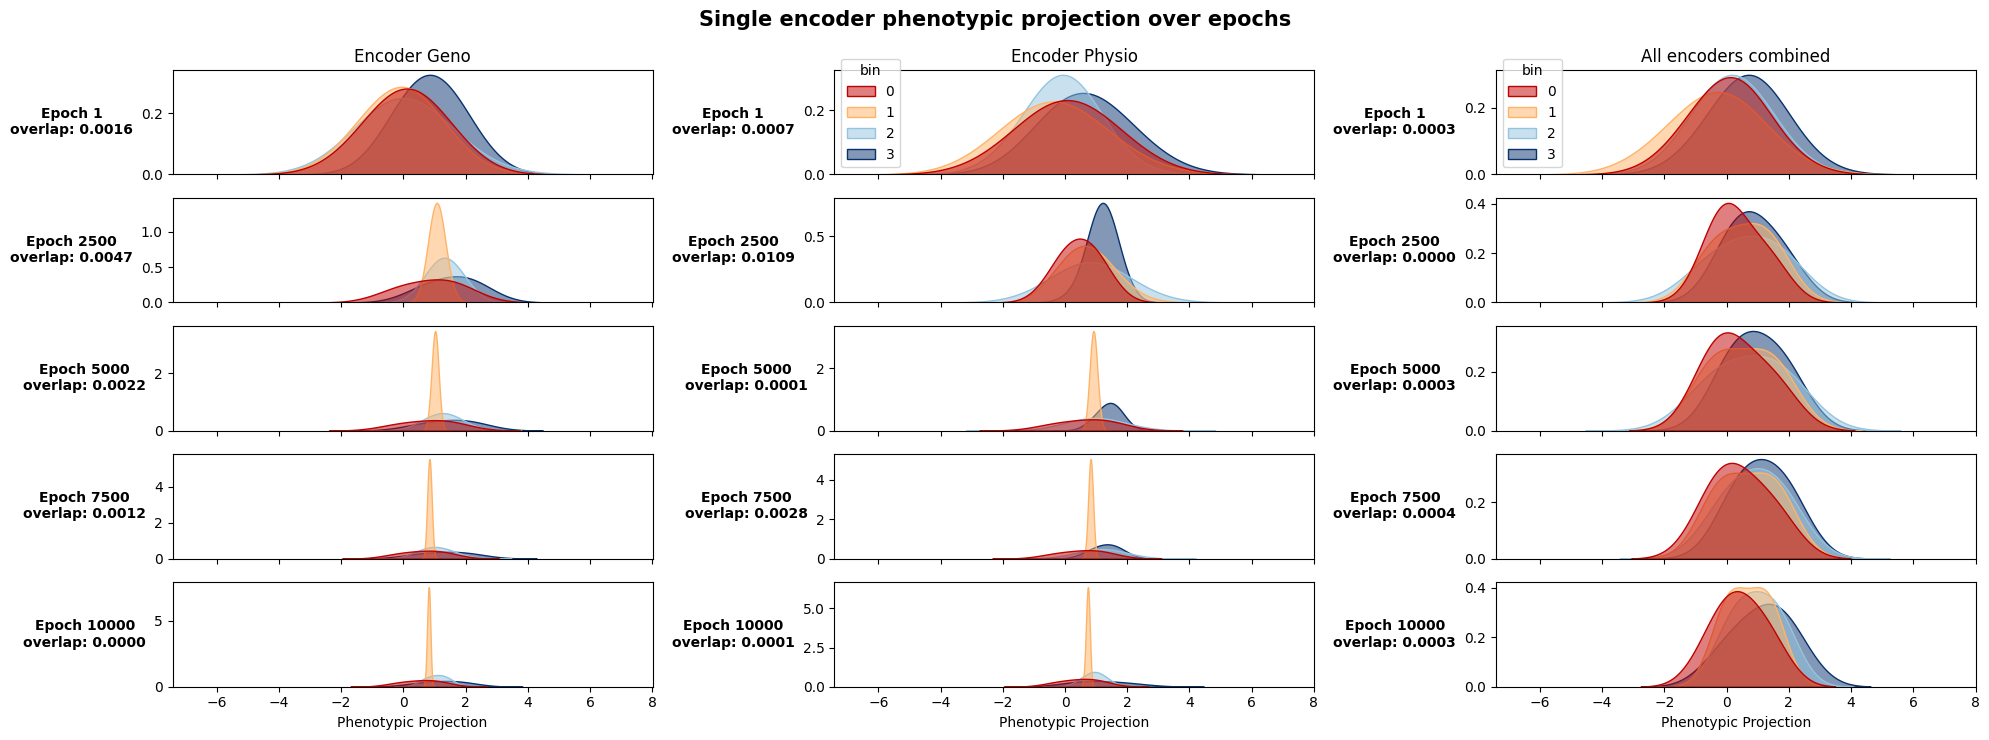

In [46]:
plot_pheno_proj_progression(output_folder, epochs)

In [47]:
#NEED TO FIX NEXT FEW CELLS 
# reconfigure shape of latents
#proj_points, overlap, overlap_val, sus, res = get_osd_from_latents_torch_new(torch.tensor(latent_space_comb.iloc[:, :latent_dim].values), latent_space_comb['Bin'].to_numpy(), torch.tensor(latent_space_comb['CFM']), d_target, temperature, mode = "together", state='eval')

In [48]:
# for when I'm testing/optimizing for only one encoder 
#proj_points = pd.read_csv(os.path.join(output_folder, f'Physio_phenotypic_projection_epoch10000.csv'), index_col=False)

Plotting phenotypic projection calculated from CFM extremes from both encoders 

In [49]:
# # plot phenotypic projection
# sns.set(style="white")
# cmap1 = cm.get_cmap('gist_heat')
# cmap2 = cm.get_cmap('Blues')
# custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
# bin_order = ['0', '1', '2', '3']
# legend_labels = ['Strong susceptible', 'Weak susceptible', 'Weak resilient', 'Strong resilient']
# plt.figure(figsize=(5.5, 3.5))
# ax = sns.kdeplot(data=proj_df, x='value',hue="bin",palette=custom_palette,fill=True,alpha=0.5,
#                  bw_adjust=3, common_norm=False)
# if not ax.legend_:
#     plt.legend(title="bin",labels=proj_df["bin"].unique(),bbox_to_anchor=(1.05, 1))
# plt.title("")
# plt.xlabel('Phenotypic projection')
# plt.title(f'Plotting phenotypic projection calculated from CFM extremes from both encoders, overlap: {overlap}')
# plt.savefig(os.path.join(output_folder, 'phenotypic_projection.png'))
# plt.tight_layout()
# plt.show()

In [50]:
zss = torch.Tensor([latent_space_comb.iloc[:501, :latent_dim].values, latent_space_comb.iloc[501:, :latent_dim].values])

Plotting midpoint phenotypic projection

In [51]:
# sus_avg = 0
# res_avg = 0
# list = zss
# comb = torch.as_tensor(latent_space_comb.iloc[:, :latent_dim].values, dtype=torch.float32)
# labels = torch.as_tensor(latent_space_comb['Label'], dtype=torch.float32)
# cfm_both = torch.as_tensor(latent_space_comb['CFM'], dtype=torch.float32)
# for zs in zss:
#     sus_anchor = torch.mean(zs[torch.topk(cfm_both[:501], k=50, largest=False).indices], dim=0)
#     res_anchor = torch.mean(zs[torch.topk(cfm_both[:501], k=50).indices], dim=0)
#     sus_avg += sus_anchor 
#     res_avg += res_anchor
# overall_overlap, projected_score, bin_value = calc_single_overlap(comb, labels, sus_avg / len(list), res_avg / len(list))
# # uncomment row below and comment rows above to train overlap for only a single encoder 
# #overall_overlap, projected_score, bin_value = calc_single_overlap(zss[1], torch.as_tensor(label_col, dtype=torch.float32), zss[1][torch.argmin(cfm_col)], zss[1][torch.argmax(cfm_col)])
# projected_scores = torch.stack((projected_score, bin_value), dim=1)

In [52]:
# proj_df = pd.DataFrame(projected_scores, columns=['value', 'bin'])
# # plot phenotypic projection
# sns.set(style="white")
# cmap1 = cm.get_cmap('gist_heat')
# cmap2 = cm.get_cmap('Blues')
# custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
# bin_order = ['0', '1', '2', '3']
# legend_labels = ['Strong susceptible', 'Weak susceptible', 'Weak resilient', 'Strong resilient']
# plt.figure(figsize=(5.5, 3.5))
# ax = sns.kdeplot(data=proj_df, x='value',hue="bin",palette=custom_palette,fill=True,alpha=0.5,
#                  bw_adjust=3, common_norm=False)
# if not ax.legend_:
#     plt.legend(title="bin",labels=proj_df["bin"].unique(),bbox_to_anchor=(1.05, 1))
# plt.title("")
# plt.xlabel('Phenotypic projection')
# plt.title(f'Midpoint phenotypic projection, overlap: {overall_overlap}')
# plt.savefig(os.path.join(output_folder, 'midpoint_phenotypic_projection.png'))
# plt.tight_layout()
# plt.show()

Plotting saved overall phenotypic projection

In [53]:
pheno_proj = pd.read_csv(os.path.join(output_folder, f'all_phenotypic_projection_epoch{epoch}.csv'), index_col=False)
pheno_proj

,value,bin,encoder,overlap,corr
0,0.546205,0.0,Geno,0.000328,0.002505
1,2.111764,3.0,Geno,0.000328,0.002505
2,1.285145,1.0,Geno,0.000328,0.002505
3,1.349804,0.0,Geno,0.000328,0.002505
4,0.519551,0.0,Geno,0.000328,0.002505
...,...,...,...,...,...
997,0.131656,0.0,Physio,0.000328,0.002505
998,0.152737,0.0,Physio,0.000328,0.002505
999,0.087333,1.0,Physio,0.000328,0.002505
1000,0.102112,1.0,Physio,0.000328,0.002505


/tmp/ipykernel_457563/1623702549.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_457563/1623702549.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


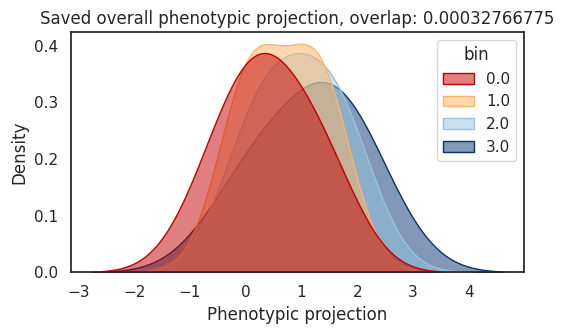

In [54]:
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
bin_order = ['0', '1', '2', '3']
legend_labels = ['Strong susceptible', 'Weak susceptible', 'Weak resilient', 'Strong resilient']
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=pheno_proj, x='value',hue="bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
if not ax.legend_:
    plt.legend(title="bin",labels=proj_df["bin"].unique(),bbox_to_anchor=(1.05, 1))
plt.title("")
plt.xlabel('Phenotypic projection')
plt.title(f'Saved overall phenotypic projection, overlap: {pheno_proj['overlap'][0]}')
plt.savefig(os.path.join(output_folder, 'midpoint_phenotypic_projection.png'))
plt.tight_layout()
plt.show()

Calculate phenotypic projection using initial method 

In [55]:
def project_row(row):
    coords = row[coord_cols].values
    proj, dist = line_coordinates_euclidean(sus, res, coords)
    return pd.Series({'Projected': proj,'Signed_Distance': dist})

In [56]:
coord_cols = latent_space_comb.iloc[:, :latent_dim].columns

In [57]:
sus = latent_space_comb.iloc[latent_space_comb['CFM'].nsmallest(50).index, :latent_dim].apply(np.mean, axis=0).values
res = latent_space_comb.iloc[latent_space_comb['CFM'].nlargest(50).index, :latent_dim].apply(np.mean, axis=0).values

projections = latent_space_comb.apply(project_row, axis=1)

df = pd.concat([
    latent_space_comb.reset_index(drop=True),
    pd.DataFrame(projections['Projected'].tolist(), columns=[f'Proj_{i+1}' for i in range(10)]),
    projections[['Signed_Distance']]], axis=1)
df.rename(columns={df.columns[-1]: 'PP'}, inplace=True)
df


,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,Proj_2,Proj_3,Proj_4,Proj_5,Proj_6,Proj_7,Proj_8,Proj_9,Proj_10,PP
0,-0.615998,-0.500066,-1.282464,0.108927,-0.386503,-0.906943,-1.086397,-1.263057,-0.379844,-1.265408,...,-0.400559,-1.061685,-0.460692,-0.808262,-0.830675,-0.929835,-1.120461,-0.833052,-1.130075,0.492199
1,-0.611741,-1.316874,-1.553513,0.118971,0.307708,-0.673481,-0.954511,-1.426783,-1.325955,-0.234853,...,-1.607548,-1.124790,-0.407557,-0.368186,-0.702926,-0.611533,-1.094088,-1.224970,-0.325978,2.097168
2,-1.730873,-1.833445,-1.972728,-0.557198,-1.312577,-1.977817,-1.966554,-2.409872,-1.675485,-1.485551,...,-0.918818,-1.088781,-0.437877,-0.619301,-0.775822,-0.793162,-1.109137,-1.001335,-0.784810,1.181344
3,-1.245506,-1.210648,-1.637838,-0.282101,-0.027009,-1.535992,-1.610427,-1.467239,-1.057641,-0.929284,...,-1.013416,-1.093727,-0.433712,-0.584810,-0.765809,-0.768215,-1.107070,-1.032052,-0.721789,1.307134
4,-0.575256,-0.504890,-1.323886,0.142306,-0.414912,-0.973004,-1.068299,-1.281882,-0.298223,-1.281833,...,-0.376605,-1.060433,-0.461747,-0.816995,-0.833210,-0.936152,-1.120985,-0.825274,-1.146033,0.460348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,-0.822026,-0.382622,-1.043201,-0.935579,-1.964841,-0.890589,-0.698090,-1.516536,-0.456205,-1.255609,...,-0.050154,-1.043365,-0.476118,-0.936021,-0.867761,-1.022242,-1.128118,-0.719273,-1.363515,0.026257
998,-0.709352,-0.365262,-0.988986,-0.989502,-1.751970,-0.889467,-0.790690,-1.486204,-0.638892,-1.320064,...,-0.076589,-1.044747,-0.474954,-0.926383,-0.864964,-1.015271,-1.127540,-0.727857,-1.345904,0.061408
999,-1.997247,-0.831062,-1.728304,-2.088413,-2.323803,-1.476625,-1.062889,-1.486228,-1.581900,-2.113966,...,-0.021683,-1.041877,-0.477371,-0.946402,-0.870775,-1.029750,-1.128740,-0.710028,-1.382482,-0.011602
1000,-1.075643,-0.890687,-1.785663,-2.173880,-2.319082,-1.692675,-1.167215,-1.712140,-1.733356,-2.162479,...,-0.029357,-1.042278,-0.477034,-0.943604,-0.869963,-1.027727,-1.128572,-0.712520,-1.377370,-0.001399


/tmp/ipykernel_457563/1907519407.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_457563/1907519407.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


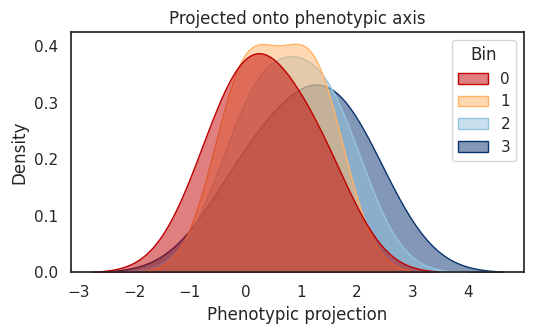

In [58]:
sns.set(style="white")
import matplotlib.cm as cm
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
bin_order = ['0', '1', '2', '3']
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=df,x='PP',hue="Bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
plt.title("Projected onto phenotypic axis")
plt.xlabel('Phenotypic projection')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'pheno_proj.png'), dpi=600)

Calculated reduced representations for visualization

In [59]:
endpoints = output['endpoints'].detach().cpu().numpy()
endpoints

array([[-0.6304756 ,  0.01755171, -1.0365448 , -0.47713923, -0.9248582 ,
        -0.87037474, -1.0425797 , -1.0995784 , -0.7416291 , -1.3998256 ],
       [-0.6277712 , -1.015516  , -1.0879401 , -0.4379382 , -0.59490347,
        -0.76834935, -0.76414573, -1.1021123 , -1.0100718 , -0.7223116 ]],
      dtype=float32)

In [60]:
random_seed

10

In [61]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
embedding = reducer.fit_transform(latent_space_comb.iloc[:, :latent_dim])
sus_endpoint = reducer.transform(endpoints[0].reshape(1, -1))
res_endpoint = reducer.transform(endpoints[1].reshape(1, -1))

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [62]:
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]

Text(0.5, 1.0, 'Compressed latent space by Diet')

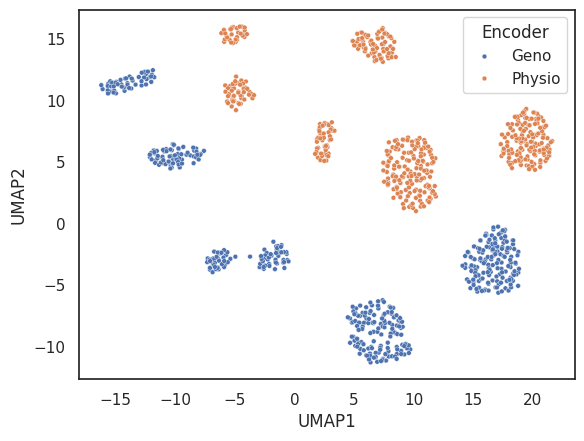

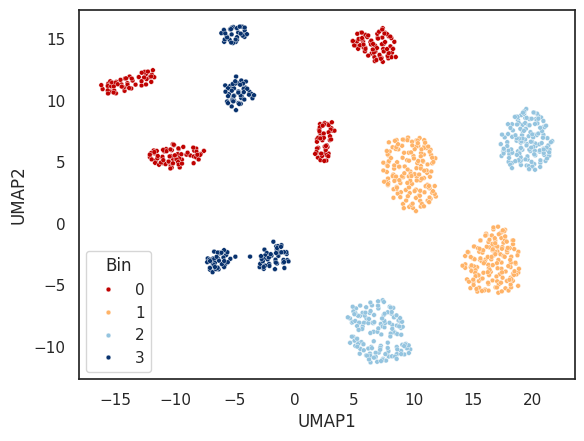

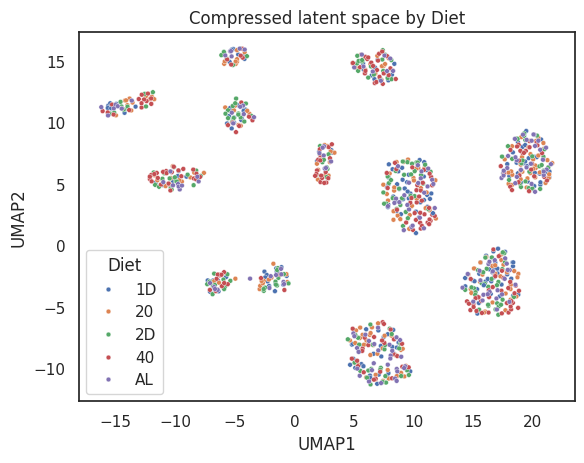

In [63]:
for hue in hues: 
    plt.figure()
    if hue == 'Bin':
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, palette=custom_palette, data=embedding_df, s=12)
    else: 
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
plt.title(f'Compressed latent space by {hue}')

In [64]:
sus_endpoint[0]

array([-4.356262,  9.886698], dtype=float32)

for hue in hues: 
    plt.figure()
    if hue == 'bin':
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, palette=custom_palette, data=embedding_df, s=12)
    else: 
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.plot(sus_endpoint[0][0], sus_endpoint[0][1], 'o', markersize=6, color='k')
    plt.plot(res_endpoint[0][0], res_endpoint[0][1], 'o', markersize=6, color='k')
    plt.title(f'Compressed latent space by {hue}')

Compute UMAP transform with endpoints included

In [65]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
new_endpoints = pd.DataFrame([endpoints[0], endpoints[1]], columns = latent_space_comb.columns[:latent_dim])
latents_with_endpoints = pd.concat([latent_space_comb.iloc[:, :latent_dim], new_endpoints], ignore_index=True)
embedding = reducer.fit_transform(latents_with_endpoints)
embedding_df = pd.DataFrame(embedding[:-2], columns=['UMAP1', 'UMAP2'])
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]
sus_endpoint = embedding[-2]
res_endpoint = embedding[-1]

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [66]:
sus_endpoint

array([-6.502867,  2.099934], dtype=float32)

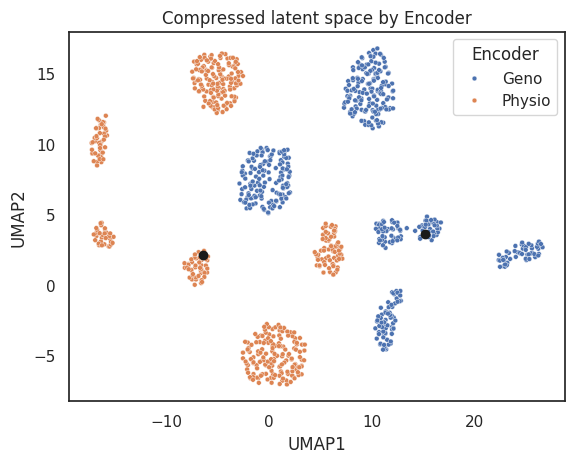

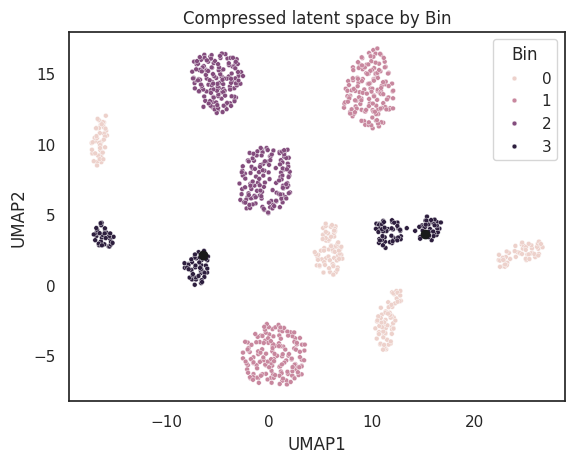

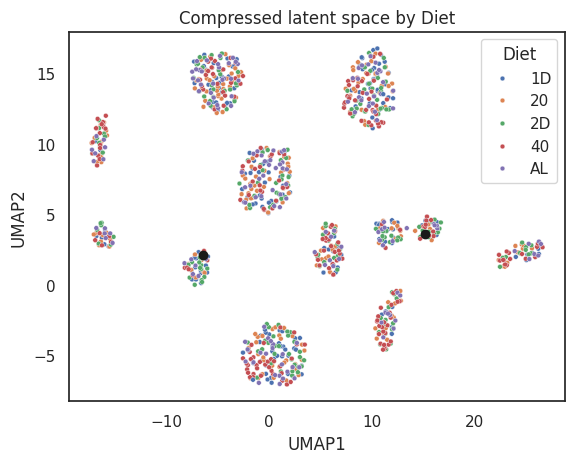

In [67]:
for hue in hues: 
    plt.figure()
    if hue == 'bin':
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, palette=custom_palette, data=embedding_df, s=12)
    else: 
        sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.plot(sus_endpoint[0], sus_endpoint[1], 'o', markersize=6, color='k')
    plt.plot(res_endpoint[0], res_endpoint[1], 'o', markersize=6, color='k')
    plt.title(f'Compressed latent space by {hue}')

/tmp/ipykernel_457563/3433105833.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Cognitive Bin",bbox_to_anchor=(-0.17, 0.3), markerscale=2.0, fontsize=17, title_fontsize=17)


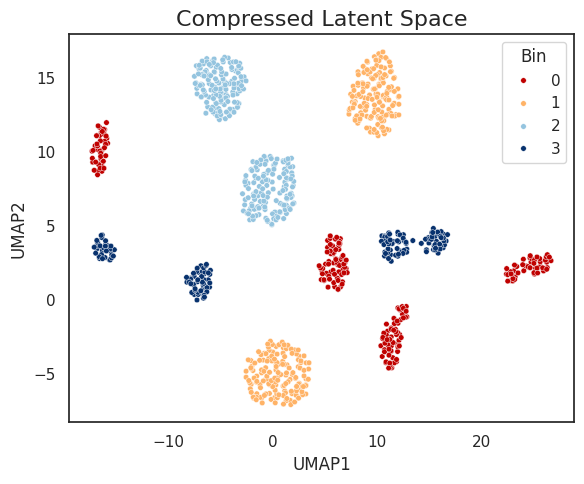

In [68]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='UMAP1', y='UMAP2', hue="Bin", palette=custom_palette, data=embedding_df, s=16)
ax.legend(title="Cognitive Bin",bbox_to_anchor=(-0.17, 0.3), markerscale=2.0, fontsize=17, title_fontsize=17)
plt.title('Compressed Latent Space', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'UMAP_colored.png'), dpi=600)

In [69]:
tsne = TSNE(n_components=2, perplexity=30, random_state=random_seed)
tsne_embeddings = tsne.fit_transform(latent_space_comb.iloc[:, :latent_dim])
tsne_embedding_df = pd.DataFrame(tsne_embeddings, columns=['t-SNE1', 't-SNE2'])
for hue in hues: 
    tsne_embedding_df[hue] = latent_space_comb[hue]

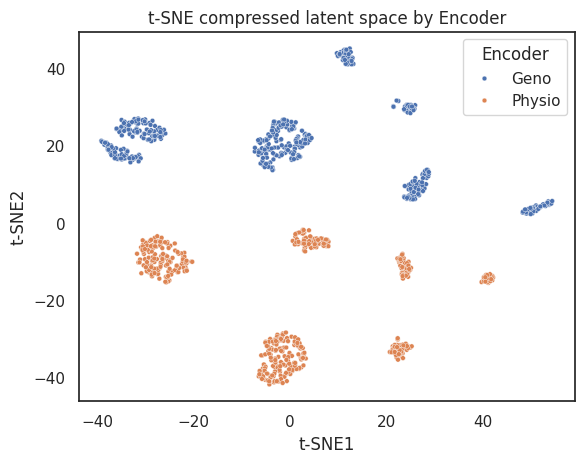

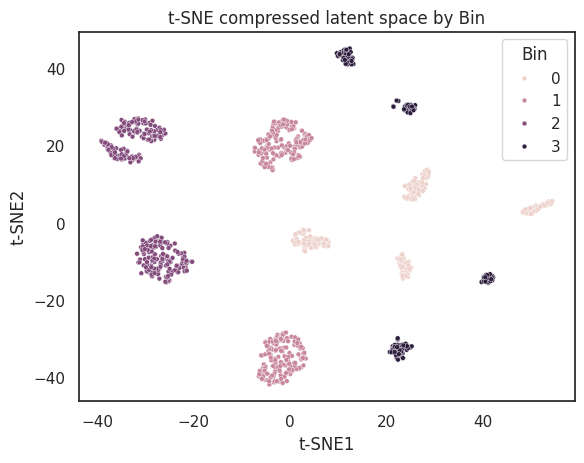

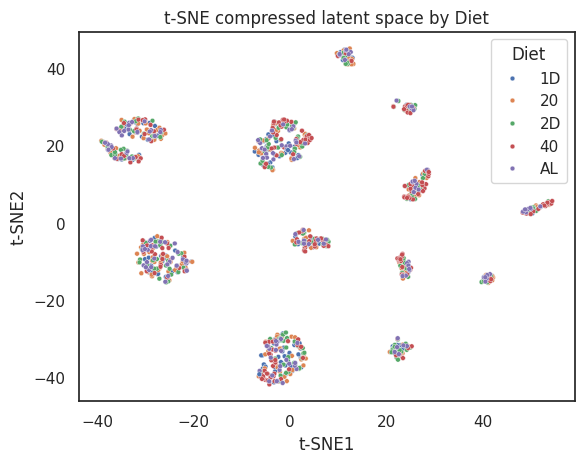

In [70]:
for hue in hues: 
    plt.figure()
    if hue == 'bin':
        sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, palette=custom_palette, data=tsne_embedding_df, s=12)
    else:
        sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, data=tsne_embedding_df, s=12)
    plt.title(f't-SNE compressed latent space by {hue}')

In [71]:
# Stop notebook at this cell for now
raise Exception("Stopping notebook execution here.")

Exception: Stopping notebook execution here.

Calculate and plot phenotypic projection

Latent space f-statistics

In [ ]:
# latent_space_PFC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/multiregion_seed22/latent_variables_epoch5000_vaePFC.csv')
# latent_space_PFC

In [ ]:
# latent_space_HC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/multiregion_seed22/latent_variables_epoch5000_vaeHC.csv')
# latent_space_HC

In [ ]:
# latent_space_comb = pd.concat([latent_space_PFC, latent_space_HC])
# latent_space_comb = latent_space_comb.reset_index()
# latent_space_comb = latent_space_comb.iloc[:, 1:]
# latent_dim=10
# dataset_abbrev = ['HC', 'PFC']

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

le = LabelEncoder()
y = le.fit_transform(latent_space_comb['encoder'])
y

array([0, 0, 0, ..., 1, 1, 1])

In [ ]:
f_values, p_values = f_classif(latent_space_comb.iloc[:, :latent_dim], y)
latents_ordered = np.argsort(f_values)[::-1]
latents_ordered

array([0, 5, 3, 2, 1, 6, 8, 7, 4, 9])

In [ ]:
latent_cols = latent_space_comb.iloc[:, :latent_dim].columns 
print('Latent feature variance correlations with encoder classification')
for col in latents_ordered:
    print(f'{latent_cols[col]}: {f_values[col], p_values[col]}')

Latent feature variance correlations with encoder classification


NameError: name 'latents_ordered' is not defined

In [ ]:
fclass_importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'f_values': f_values,
    'p_values': p_values
}).sort_values(by='f_values', ascending=False)
fclass_importance_df

,Latent variable,f_values,p_values
0,LV1,45.536855,1.540007e-11
5,LV6,17.936869,2.294011e-05
3,LV4,12.364199,4.386391e-04
2,LV3,6.067746,1.377583e-02
1,LV2,4.778317,2.883212e-02
6,LV7,2.881431,8.962230e-02
8,LV9,2.481454,1.152120e-01
7,LV8,1.059059,3.034426e-01
4,LV5,0.160387,6.888051e-01
9,LV10,0.060892,8.050948e-01


SVM to predict features relevant to encoder classification

In [ ]:
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

In [ ]:
rbf_model = SVC(kernel='rbf')
rbf_model.fit(latent_space_comb.iloc[:, :latent_dim], y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
results = permutation_importance(rbf_model, latent_space_comb.iloc[:, :latent_dim], y, n_repeats=10, random_state=random_seed)

In [ ]:
rbf_importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'Weight': results.importances_mean, 
    'Abs_weight': abs(results.importances_mean)
}).sort_values(by='Abs_weight', ascending=False)
rbf_importance_df
rbf_importance_df.to_csv(os.path.join(output_folder, 'rbf_svm_weights.csv'))

In [ ]:
for i in results.importances_mean.argsort()[::-1]:
    print(f"{latent_cols[i]}: {results.importances_mean[i]:.4f}")

LV9: 0.0662
LV10: 0.0619
LV8: 0.0423
LV7: 0.0375
LV2: 0.0331
LV4: 0.0322
LV5: 0.0302
LV3: 0.0264
LV6: 0.0258
LV1: 0.0141


In [ ]:
# with linear kernel 
linear_model = SVC(kernel='linear')
linear_model.fit(latent_space_comb.iloc[:, :latent_dim], y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
weights = linear_model.coef_[0]
importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'Weight': weights, 
    'Abs_weight': abs(weights)
}).sort_values(by='Abs_weight', ascending=False)
importance_df.to_csv(os.path.join(output_folder, 'linear_svm_weights.csv'))

Generate correlation plots between latent variables

In [ ]:
from itertools import product

In [ ]:
latent_space_comb

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual,bin_enc
0,-0.821075,-0.087403,-3.109938,5.795674,8.792862,-1.101252,-0.457701,6.632320,2.094267,3.520009,3,1.243151,HC,124,1.277393,3_HC
1,-2.015021,7.290148,10.122864,12.611817,6.056085,13.754765,0.023111,6.887195,5.687288,4.680623,3,1.243151,HC,124,1.277393,3_HC
2,-3.404760,-0.954897,21.487099,-33.262486,6.173541,-16.193356,21.466196,-40.542350,-31.126102,3.215661,3,1.243151,HC,124,1.277393,3_HC
3,-0.017482,37.088863,17.195797,-30.605204,-19.277733,-24.414824,-5.639875,28.350088,1.534736,4.688694,3,1.243151,HC,124,1.277393,3_HC
4,-0.915980,1.362210,-7.053982,-2.387872,-0.867617,4.172623,-6.082729,9.032753,-2.985671,3.499162,3,1.243151,HC,124,1.277393,3_HC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19497,-2.515494,13.251504,4.805520,-17.093998,-32.628273,-6.763705,-6.908959,17.169147,-5.345507,13.984225,1,-0.215123,PFC,28,-0.576731,1_PFC
19498,-0.832129,-5.524442,-3.264878,4.978277,10.117514,-15.615665,2.765734,41.224860,-1.811866,-17.253070,1,-0.215123,PFC,28,-0.576731,1_PFC
19499,-1.665104,-2.782021,-6.862333,2.571630,-6.245571,-16.215122,-8.369420,-0.157456,-7.539075,-1.087704,1,-0.215123,PFC,28,-0.576731,1_PFC
19500,2.370732,-7.052962,-2.519963,-3.837553,-1.990274,1.223983,-3.256374,-3.378318,-0.076304,-4.904298,1,-0.215123,PFC,28,-0.576731,1_PFC


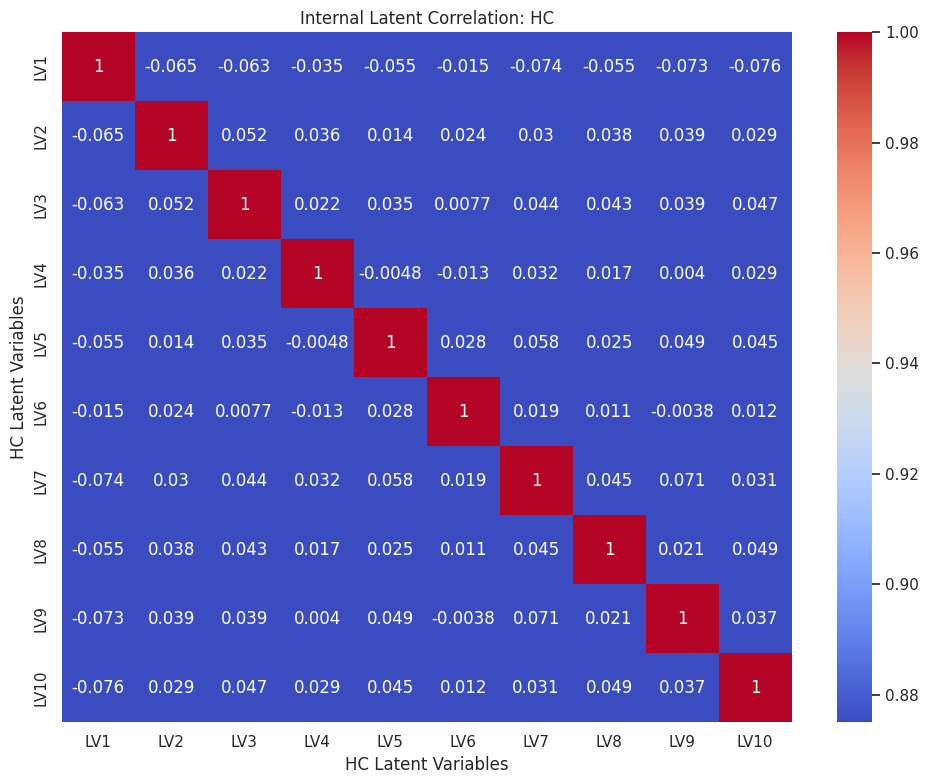

<Figure size 640x480 with 0 Axes>

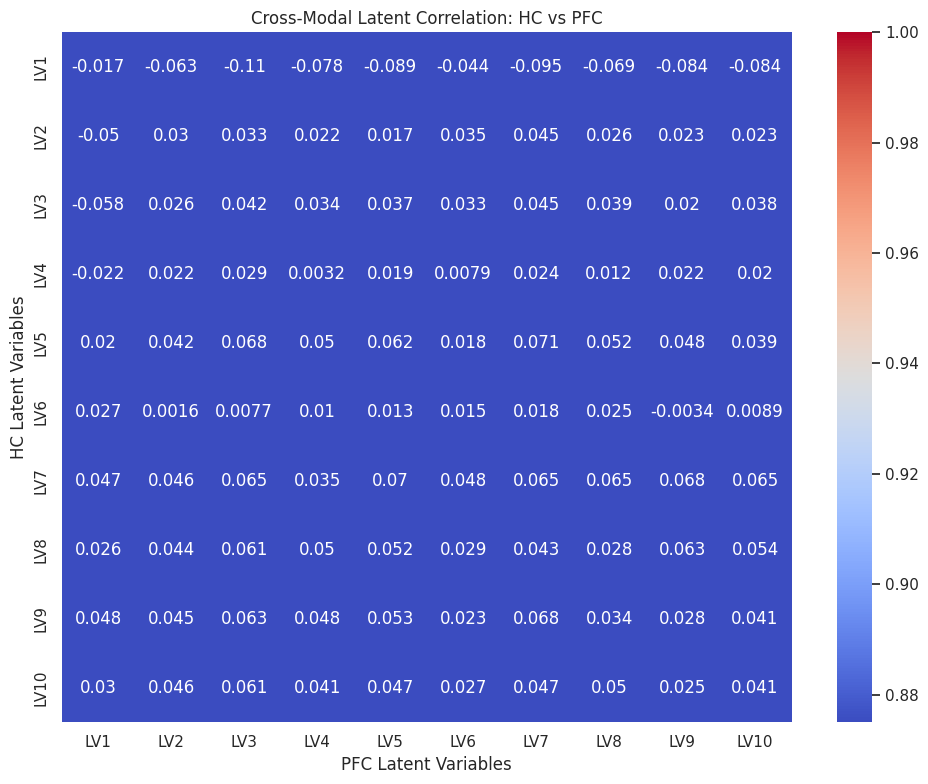

<Figure size 640x480 with 0 Axes>

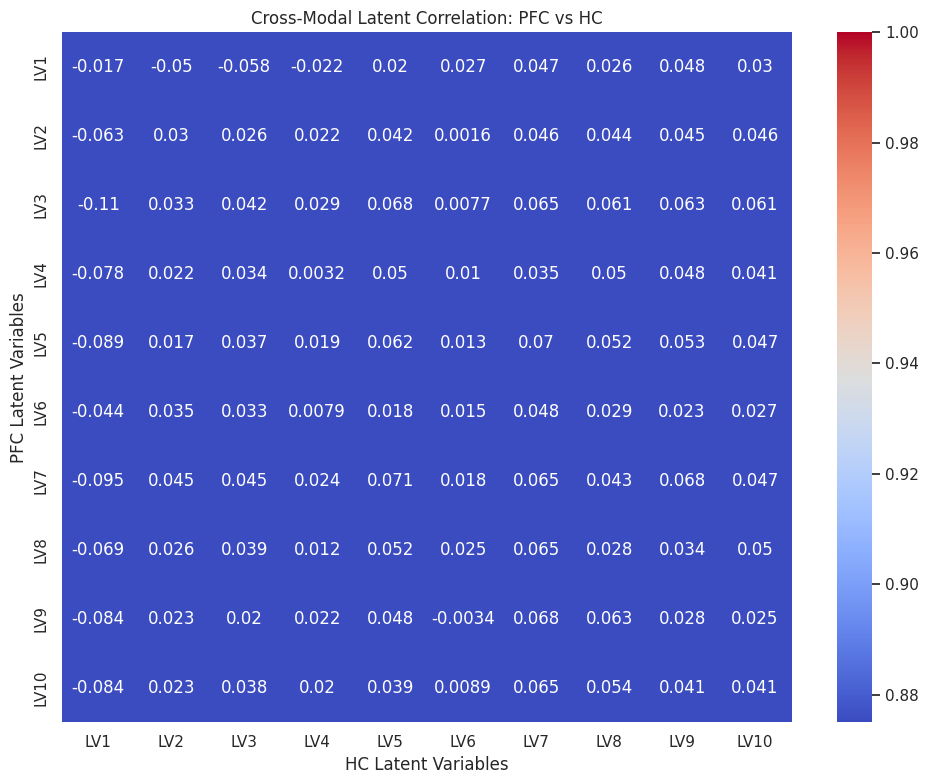

<Figure size 640x480 with 0 Axes>

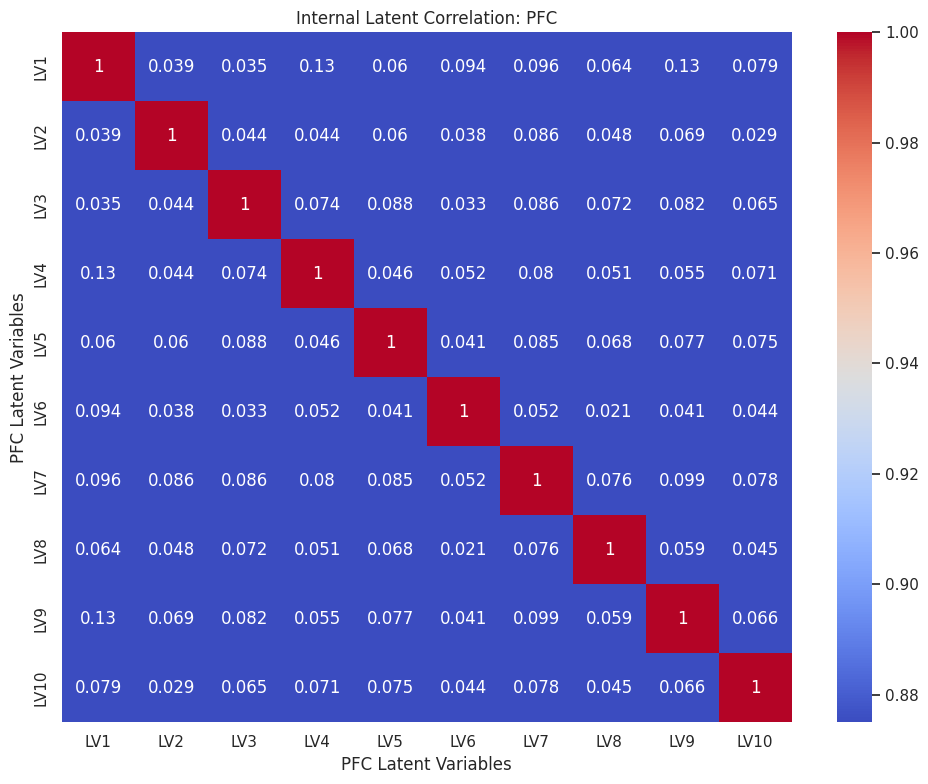

<Figure size 640x480 with 0 Axes>

In [ ]:
unique_encoders = latent_space_comb['encoder'].unique()
encoder_pairs = list(product(unique_encoders, repeat=2))
for enc1, enc2 in encoder_pairs:
    z1 = latent_space_comb[latent_space_comb['encoder'] == enc1].iloc[:, :latent_dim]
    z2 = latent_space_comb[latent_space_comb['encoder'] == enc2].iloc[:, :latent_dim]
    
    if len(z1) != len(z2):
        print(f"Skipping {enc1} vs {enc2} due to row count mismatch.")
        continue

    stacked = np.hstack((z1, z2))
    full_corr = np.corrcoef(stacked.T)
    cross_corr = full_corr[:latent_dim, latent_dim:]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cross_corr, 
        annot=True, 
        cmap='coolwarm', 
        xticklabels=latent_cols,
        yticklabels=latent_cols, 
        vmin=0.875, 
        vmax=1
    )
    
    plt.xlabel(f"{enc2} Latent Variables", fontsize=12)
    plt.ylabel(f"{enc1} Latent Variables", fontsize=12)
    if enc1 == enc2:
        plt.title(f"Internal Latent Correlation: {enc1}")
    else:
        plt.title(f"Cross-Modal Latent Correlation: {enc1} vs {enc2}")
    plt.tight_layout()
    plt.show()
    if enc1 == enc2:
        plt.savefig(os.path.join(output_folder, f"InternalLatentCorrelation:{enc1}.png"))
    else:
        plt.savefig(os.path.join(output_folder, f"Cross-ModalLatentCorrelation:{enc1}vs{enc2}.png"))